In [1]:
import scipy as sp
import numpy as np
import os
import matplotlib.pyplot as plt
import sympy as sp
from sympy.abc import x, y

Text(0, 0.5, 'x$^*$')

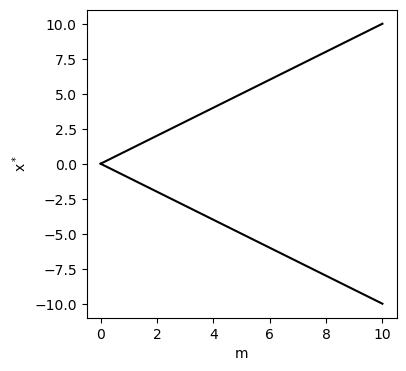

In [23]:
m = np.linspace(0, 10)



fig, ax = plt.subplots(1,1, figsize= (4,4))
ax.plot(m, m, color = 'k')
ax.plot(m, -m, color = 'k')
ax.set_xlabel("m")
ax.set_ylabel(r"x$^*$")


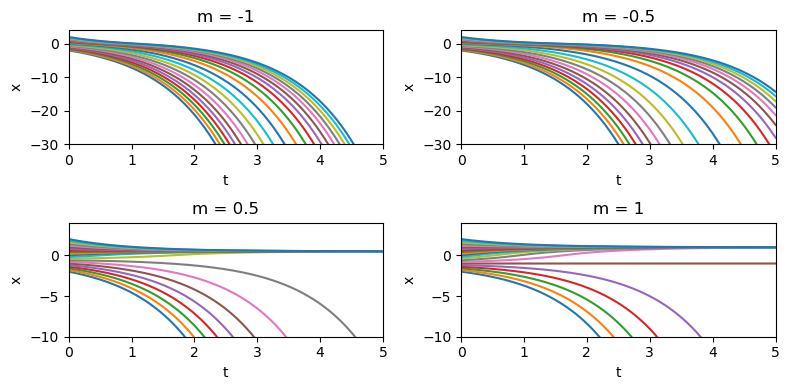

In [ ]:
ms = [-1, -0.5, 0.5, 1]
fig, ax = plt.subplots(2,2, figsize = (8,4))
ax = ax.flatten()
for j in range(4):
    for i in range(21):
        data = np.loadtxt(f"lab_{i}_{j}.dat").T
        ax[j].plot(data[0], data[1])
    ax[j].set_ylim(-30, 4)
    if j >1:
        ax[j].set_ylim(-10, 4)
    ax[j].set_xlim(0,5)
    ax[j].set_ylabel("x")
    ax[j].set_xlabel("t")
    ax[j].set_title(f"m = {ms[j]}")

fig.tight_layout()

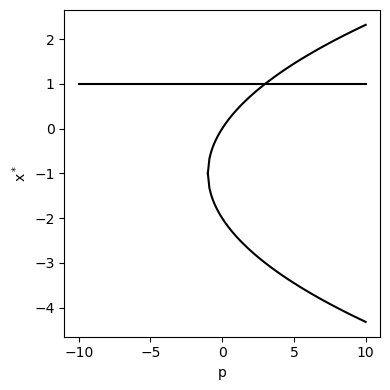

In [45]:
fig, ax = plt.subplots(1,1, figsize = (4,4))

p = np.linspace(-1, 10, 100)

x1 = lambda p: -1 - np.sqrt(1 + p)
x2 = lambda p: -1 + np.sqrt(1 + p)
x3 = lambda p: np.ones_like(p)

xs = [x1, x2]

for x in xs:
    ax.plot(p, x(p), color = 'k')
new_p = np.linspace(-10, 10, 200)
ax.plot(new_p, x3(new_p), color = 'k')

ax.set_xlabel('p')
ax.set_ylabel(r"x$^*$")

fig.tight_layout()





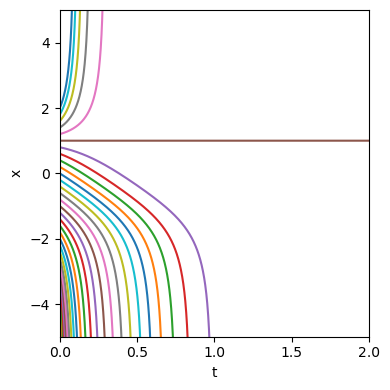

In [51]:
fig, ax = plt.subplots(1,1,figsize = (4,4))
j = 0
for i in range(31):
    data = np.loadtxt(f"lab_{i}_{j}.dat").T
    ax.plot(data[0], data[1])

ax.set_ylim(-5, 5)
ax.set_xlim(0,2)
ax.set_ylabel("x")
ax.set_xlabel("t")
fig.tight_layout()

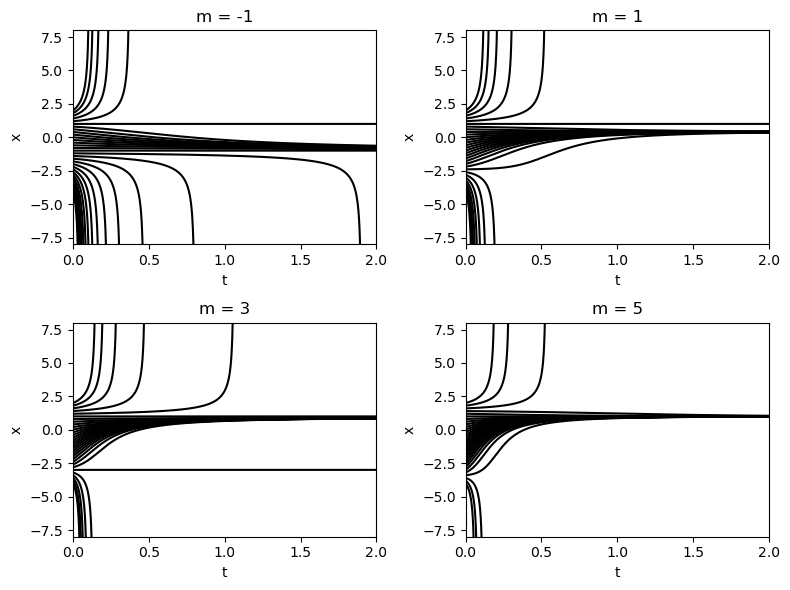

In [15]:
fig, ax = plt.subplots(2,2,figsize = (8,6))
ax = ax.flatten()
ms = [-1, 1, 3, 5]
for j in range(4):
    for i in range(31):
        data = np.loadtxt(f"lab_{i}_{j}.dat").T
        ax[j].plot(data[0], data[1], color = 'k')

    ax[j].set_ylim(-8, 8)
    ax[j].set_xlim(0,2)
    ax[j].set_ylabel("x")
    ax[j].set_xlabel("t")
    ax[j].set_title(f"m = {ms[j]}")
fig.tight_layout()
plt.savefig("lab4b_bifurcation_diagram.png", dpi = 300)

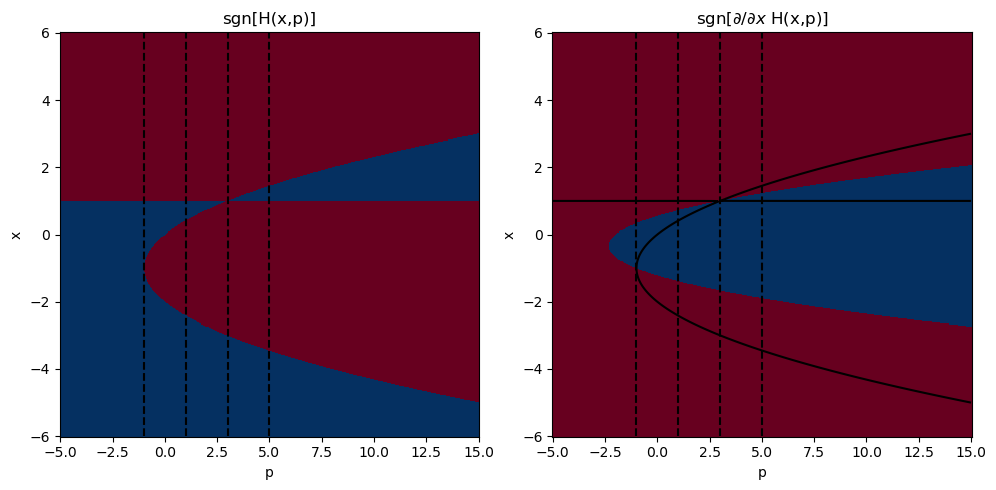

In [72]:
def H(x, p):
    return (x - 1)*(x**2 + 2*x - p)

def H_prime(x, p):
    return 3*x**2 + 2*x - p - 2

p_vals = np.linspace(-5, 15, 400)
x_vals = np.linspace(-6, 6, 400)
P, X = np.meshgrid(p_vals, x_vals)

fig, ax = plt.subplots(1, 2, figsize=(10,5))


Z = H(X, P)
Z_plot = np.sign(Z)
im = ax[0].pcolormesh(p_vals, x_vals, Z_plot, shading='auto', cmap='RdBu_r')
ax[0].set_xlabel('p')
ax[0].set_ylabel('x')
ax[0].vlines(-1, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[0].vlines(3, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[0].vlines(1, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[0].vlines(5, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[0].set_title('sgn[H(x,p)]')

Z = H_prime(X, P)
Z_plot = np.sign(Z)
im = ax[1].pcolormesh(p_vals, x_vals, Z_plot, shading='auto', cmap='RdBu_r')
ax[1].set_xlabel('p')
ax[1].set_ylabel('x')
ax[1].vlines(-1, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[1].vlines(3, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[1].vlines(1, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[1].vlines(5, ymin= -6, ymax = 6, color='k', linestyle='--')
ax[1].contour(p_vals, x_vals, H(X, P), levels=[0], colors='k')
ax[1].set_title(r'sgn[$\partial/\partial x$ H(x,p)]')
fig.tight_layout()